In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import joblib 
from sklearn.metrics import mean_absolute_error,mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
val_df  = pd.read_parquet("../data/processed/val_split.parquet")
test_df = pd.read_parquet("../data/processed/test_split.parquet")

model_naive     = joblib.load("../artifacts/models/model_naive.pkl")
model_corrected = joblib.load("../artifacts/models/model_corrected.pkl")
feature_cols    = joblib.load("../artifacts/models/feature_cols.pkl")


In [3]:
X_test = test_df[feature_cols]
y_test = test_df['sale_amount']

pred_naive     = model_naive.predict(X_test)
pred_corrected = model_corrected.predict(X_test)

print(f"Predictions generated for {len(y_test)} rows")

Predictions generated for 450000 rows


In [4]:
def evaluate(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f"\n{name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  WAPE: {wape:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'wape': wape, 'mape': mape}

metrics_naive     = evaluate(y_test, pred_naive,     "Naive Model (Test Set)")
metrics_corrected = evaluate(y_test, pred_corrected, "Corrected Model (Test Set)")


Naive Model (Test Set)
  MAE:  0.3693
  RMSE: 0.6559
  WAPE: 0.3190
  MAPE: 242971852.30%

Corrected Model (Test Set)
  MAE:  0.3611
  RMSE: 0.6023
  WAPE: 0.3119
  MAPE: 298041843.30%


In [5]:
import json
import os

os.makedirs("../artifacts/metrics", exist_ok=True)

metrics = {
    "naive":     metrics_naive,
    "corrected": metrics_corrected
}

with open("../artifacts/metrics/evaluation.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved to artifacts/metrics/evaluation.json")

Saved to artifacts/metrics/evaluation.json


In [6]:
stockout_mask = test_df['stockout_flag'] == 1

sample = test_df[stockout_mask].head(100).copy()
sample['pred_naive']     = pred_naive[stockout_mask][:100]
sample['pred_corrected'] = pred_corrected[stockout_mask][:100]


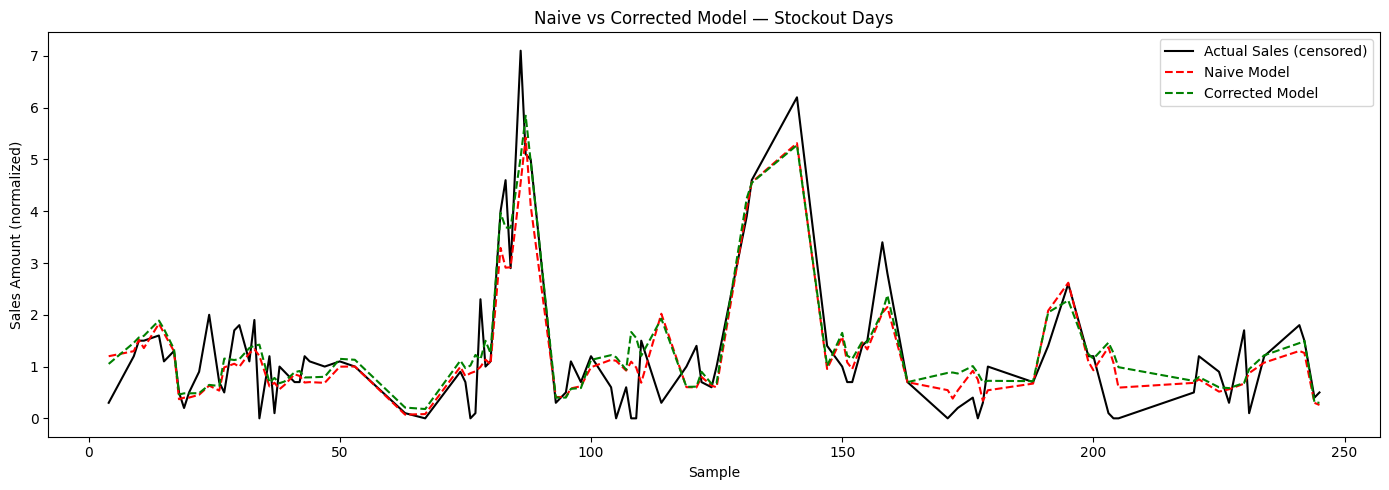

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(sample.index, sample['sale_amount'],    label='Actual Sales (censored)', color='black', linewidth=1.5)
plt.plot(sample.index, sample['pred_naive'],     label='Naive Model',             color='red',   linestyle='--')
plt.plot(sample.index, sample['pred_corrected'], label='Corrected Model',         color='green', linestyle='--')
plt.title('Naive vs Corrected Model — Stockout Days')
plt.xlabel('Sample')
plt.ylabel('Sales Amount (normalized)')
plt.legend()
plt.tight_layout()
plt.savefig("../artifacts/reports/naive_vs_corrected.png", dpi=150)
plt.show()

In [9]:
importance = pd.Series(
    model_corrected.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(15)


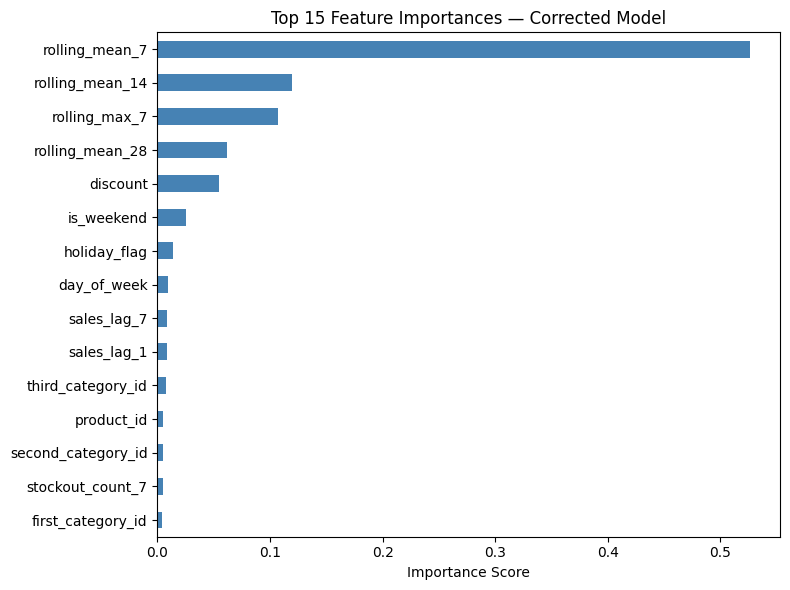

Saved


In [10]:
plt.figure(figsize=(8, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Corrected Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig("../artifacts/reports/feature_importance.png", dpi=150)
plt.show()
print("Saved")